In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf




In [4]:
df_timeseries = pd.read_csv("/Users/zahrataghizadeh/Desktop/ADA/YouNiverse/df_timeseries_en.tsv.gz", compression="infer", sep="\t")
#df_metadata = pd.read_csv("/Users/zahrataghizadeh/Desktop/ADA/YouNiverse/yt_metadata_en.jsonl.gz", compression="infer", sep="\t")

In [144]:
# check the columns of the dataframe
print(df_timeseries.columns)

# check the shape of the dataframe
print(df_timeseries.shape)
#get the unique values for category column
print(df_timeseries['category'].unique())

# only get the rows where the column 'category' is Sports
df_timeseries_sports = df_timeseries[df_timeseries['category'] == 'Sports']
print('Sport channel number: ', df_timeseries_sports.shape)

Index(['channel', 'category', 'datetime', 'views', 'delta_views', 'subs',
       'delta_subs', 'videos', 'delta_videos', 'activity', 'month', 'year',
       'is_sports', 'post_treatment', 'interaction'],
      dtype='object')
(18872499, 15)
['Film and Animation' 'Music' 'Comedy' 'Gaming' 'Science & Technology'
 'Sports' 'Entertainment' 'Education' 'Nonprofits & Activism'
 'People & Blogs' 'Howto & Style' 'News & Politics' 'Travel & Events'
 'Autos & Vehicles' 'Pets & Animals' nan]
Sport channel number:  (762263, 15)


In [109]:
# datetime is in the following format: 2020-01-01 00:00:00, YYYY/MM/DD
df_timeseries_sports['datetime'] = pd.to_datetime(df_timeseries_sports['datetime'])
# get the latest and the earliest date
print('Latest date: ', df_timeseries_sports['datetime'].max())
print('Earliest date: ', df_timeseries_sports['datetime'].min())


Latest date:  2019-09-30 01:00:00
Earliest date:  2015-06-01 00:00:00


/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_13083/2262375735.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeseries_sports['datetime'] = pd.to_datetime(df_timeseries_sports['datetime'])


In [ ]:
# group the data by month and year
df_timeseries_sports['month'] = df_timeseries_sports['datetime'].dt.month
df_timeseries_sports['year'] = df_timeseries_sports['datetime'].dt.year
df_timeseries_sports_grouped_main = df_timeseries_sports.groupby(['year', 'month'])

In [102]:

df_timeseries_sports_grouped = df_timeseries_sports_grouped_main['delta_views'].mean()
df_timeseries_sports_grouped = df_timeseries_sports_grouped.reset_index()
print(df_timeseries_sports_grouped)

    year  month    delta_views
0   2015      6   16344.050000
1   2015      7   55903.635417
2   2015      8  264010.596032
3   2015      9  480352.385957
4   2015     10  618909.635589
5   2015     11  567814.635200
6   2015     12   56715.732856
7   2016      1   37958.715809
8   2016      2   53353.837721
9   2016      3   17898.050116
10  2016      4   18831.943304
11  2016      5   18486.937114
12  2016      6   23659.597981
13  2016      7   28560.011136
14  2016      8   36283.163214
15  2016      9   38200.691380
16  2016     10  138620.659143
17  2016     11  198756.431135
18  2016     12  198652.485545
19  2017      1  251775.939914
20  2017      2  209345.627091
21  2017      3  223046.198571
22  2017      4  240407.520806
23  2017      5  244711.485037
24  2017      6  247804.196554
25  2017      7  241672.863222
26  2017      8  239582.018165
27  2017      9  235464.785195
28  2017     10  245540.746946
29  2017     11  276816.850754
30  2017     12  268223.802454
31  2018

In [101]:
# plot the number of views for the sports category during time, on the x-axis have discritized time in months and on the y-axis the number of views
df_timeseries_sports_grouped = df_timeseries_sports_grouped_main['views'].mean()
df_timeseries_sports_grouped = df_timeseries_sports_grouped.reset_index()
print(df_timeseries_sports_grouped)

    year  month         views
0   2015      6  2.186953e+06
1   2015      7  1.465184e+06
2   2015      8  2.304641e+06
3   2015      9  3.729544e+06
4   2015     10  5.595134e+06
5   2015     11  8.243179e+06
6   2015     12  8.021392e+06
7   2016      1  6.172056e+06
8   2016      2  3.020088e+06
9   2016      3  2.932298e+06
10  2016      4  2.870776e+06
11  2016      5  2.863801e+06
12  2016      6  3.086038e+06
13  2016      7  3.783385e+06
14  2016      8  4.547746e+06
15  2016      9  4.734692e+06
16  2016     10  1.817949e+07
17  2016     11  2.231088e+07
18  2016     12  2.284344e+07
19  2017      1  2.326573e+07
20  2017      2  2.324259e+07
21  2017      3  2.357718e+07
22  2017      4  2.412893e+07
23  2017      5  2.475685e+07
24  2017      6  2.554566e+07
25  2017      7  2.624225e+07
26  2017      8  2.690642e+07
27  2017      9  2.758614e+07
28  2017     10  2.822390e+07
29  2017     11  2.891128e+07
30  2017     12  3.060987e+07
31  2018      1  2.938445e+07
32  2018  

In [100]:
# plot the number of delta_subs for the sports category during time, on the x-axis have discritized time in months and on the y-axis the number of views
df_timeseries_sports_grouped = df_timeseries_sports_grouped_main['delta_subs'].mean()
df_timeseries_sports_grouped = df_timeseries_sports_grouped.reset_index()
print(df_timeseries_sports_grouped)

    year  month   delta_subs
0   2015      6    44.650000
1   2015      7   182.835417
2   2015      8   765.659524
3   2015      9  2179.483796
4   2015     10  2342.125551
5   2015     11  1723.283624
6   2015     12   116.662605
7   2016      1   114.152192
8   2016      2   125.394027
9   2016      3    37.547322
10  2016      4    38.091896
11  2016      5    42.851590
12  2016      6    52.277634
13  2016      7    60.019851
14  2016      8    85.987613
15  2016      9    89.790338
16  2016     10   343.740364
17  2016     11   562.116558
18  2016     12   522.603408
19  2017      1   563.404550
20  2017      2   529.250547
21  2017      3   564.117975
22  2017      4   697.308458
23  2017      5   628.108127
24  2017      6   718.140672
25  2017      7   664.473549
26  2017      8   698.476332
27  2017      9   654.254509
28  2017     10   652.520842
29  2017     11   665.595213
30  2017     12   762.780809
31  2018      1   883.374399
32  2018      2   952.629250
33  2018      

In [89]:
# plot the number of subs for the sports category during time, on the x-axis have discritized time in months and on the y-axis the number of views
df_timeseries_sports_grouped = df_timeseries_sports_grouped_main['subs'].sum()
df_timeseries_sports_grouped = df_timeseries_sports_grouped.reset_index()


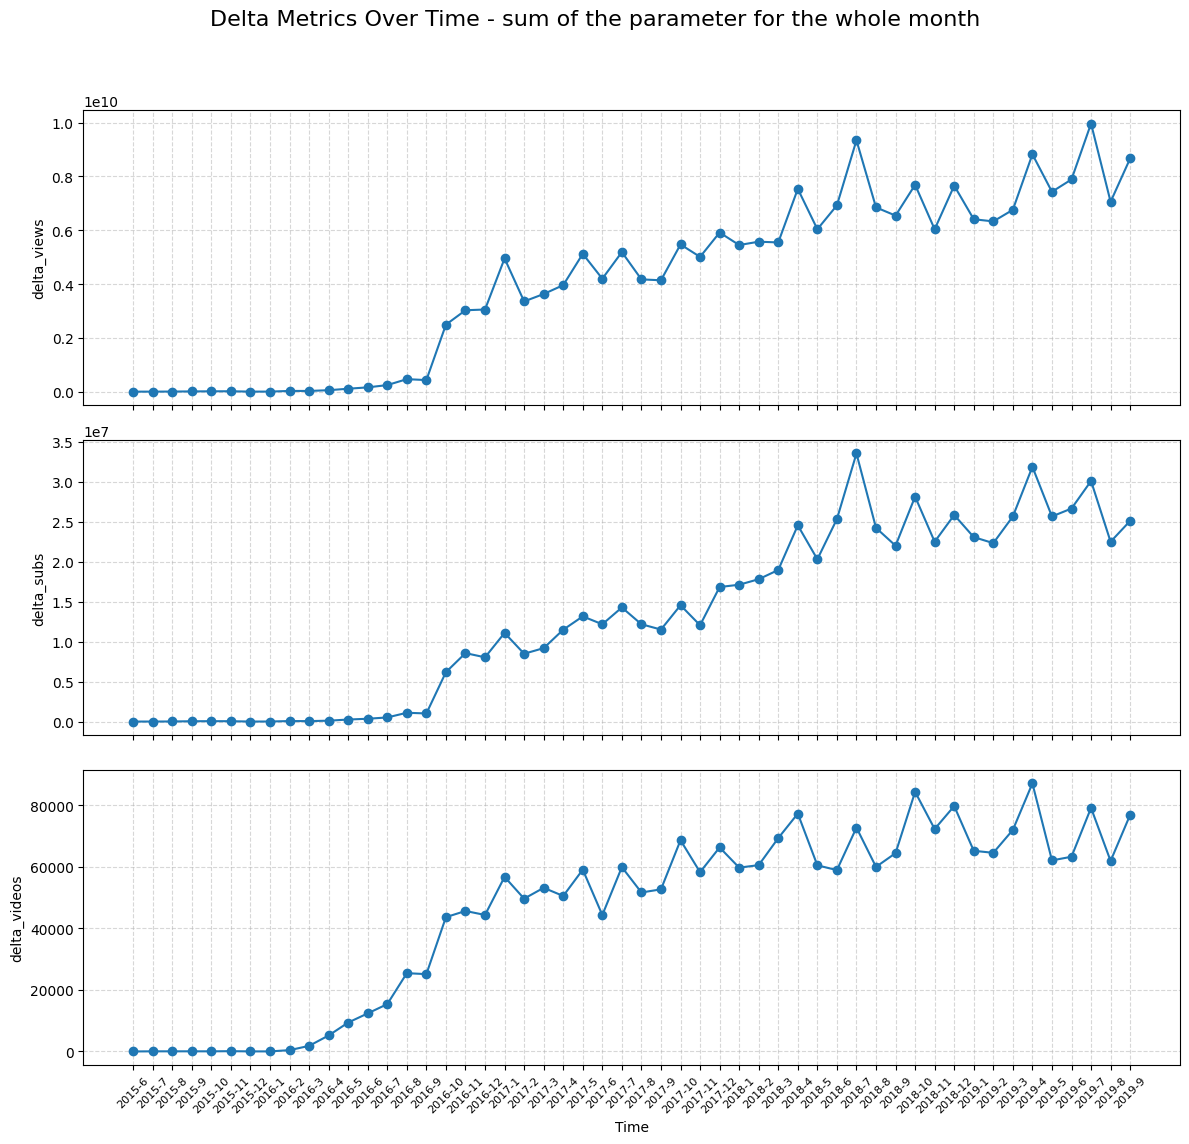

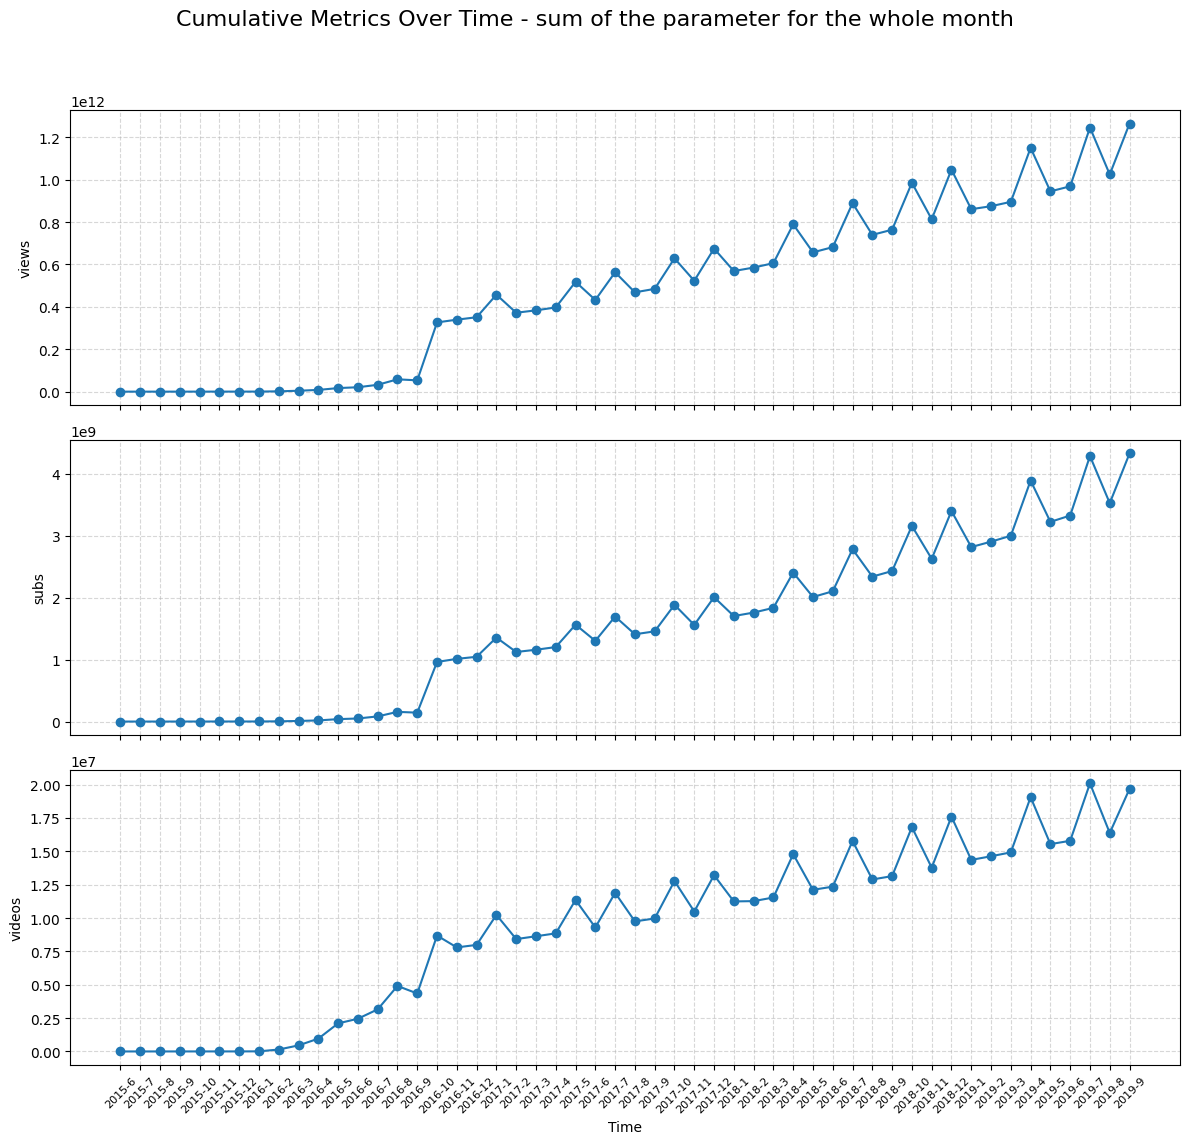

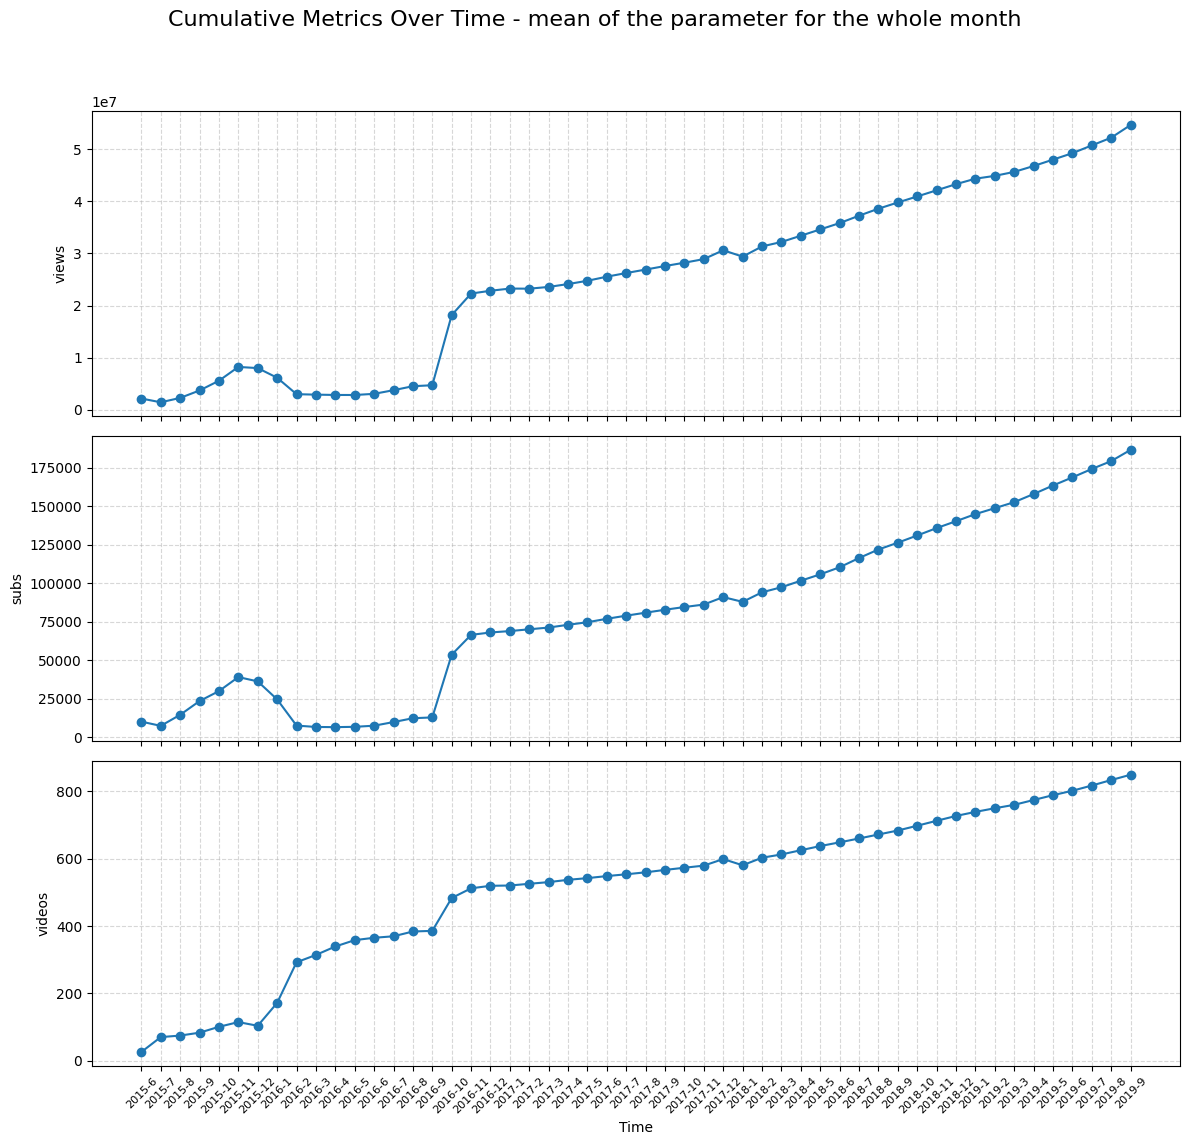

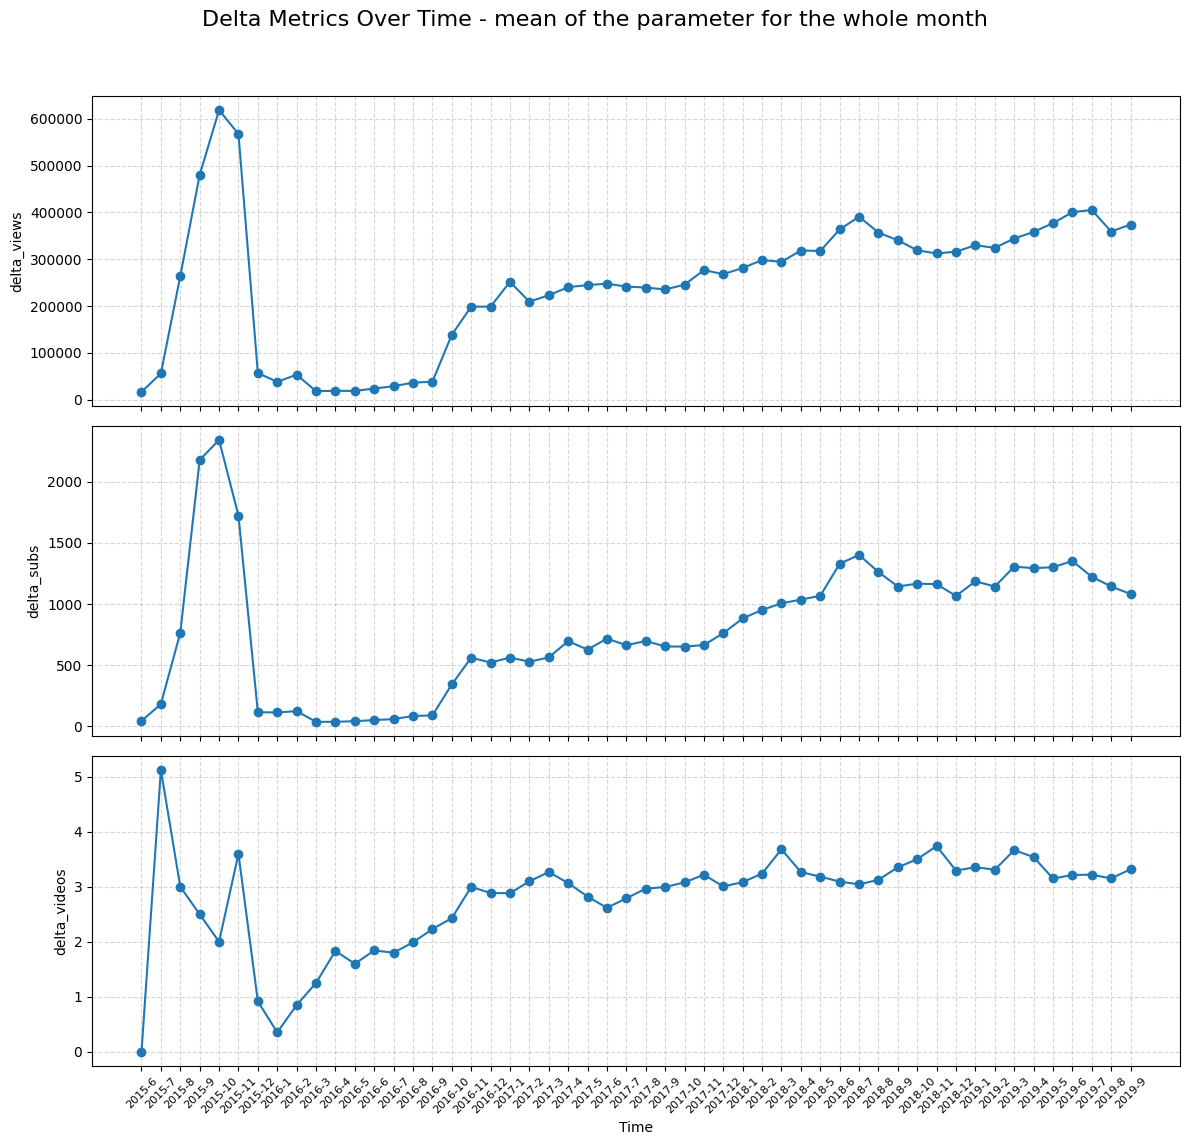

In [104]:
def plot_columns(df, columns, title, method):
    num_cols = len(columns)
    
    # Create subplots with shared x-axis and increased figure size
    fig, axs = plt.subplots(num_cols, 1, figsize=(12, 4 * num_cols), sharex=True)
    
    if num_cols == 1:
        axs = [axs]
    
    for i, column in enumerate(columns):
        if method == 'sum':
            df_grouped = df.groupby(['year', 'month'])[column].sum().reset_index()
        elif method == 'mean':
            df_grouped = df.groupby(['year', 'month'])[column].mean().reset_index()
        time_str = df_grouped['year'].astype(str) + '-' + df_grouped['month'].astype(str)
        
        # Plot the data
        axs[i].plot(time_str, df_grouped[column], marker='o', linestyle='-')
        axs[i].set_ylabel(column)
        
        axs[i].grid(True, linestyle='--', alpha=0.5)
        
        if i < num_cols - 1:
            axs[i].tick_params(labelbottom=False)  # Hide x-axis labels
        else:
            axs[i].set_xlabel('Time')
            axs[i].tick_params(axis='x', labelsize=8, rotation=45)
    
    plt.tight_layout()
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    plt.show()

columns = ['delta_views', 'delta_subs', 'delta_videos', 'views', 'subs', 'videos']
plot_columns(df_timeseries_sports, columns[0:3], 'Delta Metrics Over Time - sum of the parameter for the whole month', 'sum')
plot_columns(df_timeseries_sports, columns[3:], 'Cumulative Metrics Over Time - sum of the parameter for the whole month', 'sum')

plot_columns(df_timeseries_sports, columns[3:], 'Cumulative Metrics Over Time - mean of the parameter for the whole month', 'mean')
plot_columns(df_timeseries_sports, columns[0:3], 'Delta Metrics Over Time - mean of the parameter for the whole month', 'mean')


Based on the plots we can see that there are some spikee in the data. 
Now, I try to list the important events in each month and year corresponding to the spikes.

2017-01
- NFL Playoffs – Key games leading up to the Super Bowl took place throughout January, engaging American football fans.
- Australian Open (Tennis) – Began on January 16, 2017; this Grand Slam tournament attracted significant global attention, especially with stars like Roger Federer and - Serena Williams competing.
- Transfer Window (Soccer) – The European soccer transfer window in January spurred rumors, analysis, and updates that are popular on sports channels.

2017-05
- UEFA Champions League Semifinals and Final – The semifinals concluded in early May, leading up to the final on June 3, with intense interest in teams like Real Madrid and Juventus.
- NBA Playoffs – The NBA playoffs were in full swing, capturing fans’ attention as teams competed to reach the Finals.
- Stanley Cup Playoffs (NHL) – The NHL playoffs were also ongoing, especially popular in North America.
- French Open (Tennis) – Started on May 28, 2017, kicking off another Grand Slam event that attracts global tennis fans.
- Formula 1 Monaco Grand Prix – Held on May 28, 2017, one of the most prestigious races in F1, drawing significant viewership

2017-10
- MLB World Series – The playoffs led to the World Series starting on October 24, 2017, with the Houston Astros ultimately winning against the Los Angeles Dodgers. Baseball fans were highly engaged during this period.
- NFL Regular Season – The NFL season was in full swing, drawing considerable attention in the U.S. as games intensified.
NBA Season Start – The 2017-18 NBA season began on October 17, 2017, bringing excitement as fans followed opening games and team dynamics.
- NHL Regular Season – The NHL season had just started in early October, engaging hockey fans.
- European Soccer Leagues – Major European leagues, such as the English Premier League, La Liga, and Serie A, were well underway, generating global viewership and content around matches and player performance.

2018-04
- UEFA Champions League Quarterfinals – Big matches, like Manchester United vs. Barcelona, attracted global attention.
- NBA Playoffs Start – Began on April 13, engaging basketball fans.
- Masters Tournament – Tiger Woods won his first major in over a decade, creating huge buzz.
- MLB Season Kickoff – Early regular-season games for baseball fans.

2018-07
- FIFA World Cup Final: The final match of the FIFA World Cup in Russia took place on July 15, 2018, with France defeating Croatia. 
- Wimbledon Finals: The Wimbledon tennis tournament concluded in July, with the finals happening on July 14 (women’s singles) and July 15 (men’s singles). 
- Tour de France: The Tour de France began on July 7, 2018, and continued through the rest of the month. 


2018-10
- MLB World Series – The playoffs led to the World Series starting on October 23, 2018, with the Boston Red Sox ultimately defeating the Los Angeles Dodgers. This event attracts a lot of engagement from baseball fans.
- NFL Regular Season – The NFL season was in full swing, with fans closely following games and team performances.
- NBA Season Start – The 2018-19 NBA season began on October 16, 2018, bringing excitement as fans tuned in to watch opening games and new player lineups.
- NHL Regular Season – The NHL season also started in early October.
- European Soccer Leagues – Major European leagues, including the Premier League, La Liga, and Serie A, were in full action, with popular matches generating high viewership worldwide.

2019-04
- UEFA Champions League Quarterfinals – High-stakes matches, such as Manchester United vs. Barcelona and Tottenham vs. Manchester City, attracted global attention.
- NBA Playoffs Start – Began on April 13, 2019, engaging basketball fans eager to follow the postseason action.
- Masters Tournament (Golf) – From April 11 to April 14, 2019, Tiger Woods won his first major in over a decade, a historic victory that created significant media buzz.
- Start of MLB Season – The early regular season was underway, engaging baseball fans.
- Formula 1 Races – The Chinese Grand Prix on April 14, 2019, marked the 1000th race in F1 history, drawing attention from motorsports fans.



Olympics
- Rio 2016 Summer Olympics – The 2016 Summer Olympics in Rio de Janeiro, Brazil, took place from August 5 to August 21, 2016. (a small spike can be seen)
- PyeongChang 2018 Winter Olympics – The 2018 Winter Olympics in PyeongChang, South Korea, were held from February 9 to February 25, 2018. (no spikes can be seen)

delta_views       0
is_sports         0
post_treatment    0
interaction       0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:            delta_views   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2748.
Date:                Fri, 01 Nov 2024   Prob (F-statistic):               0.00
Time:                        14:30:34   Log-Likelihood:            -3.1396e+08
No. Observations:            18872499   AIC:                         6.279e+08
Df Residuals:                18872495   BIC:                         6.279e+08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

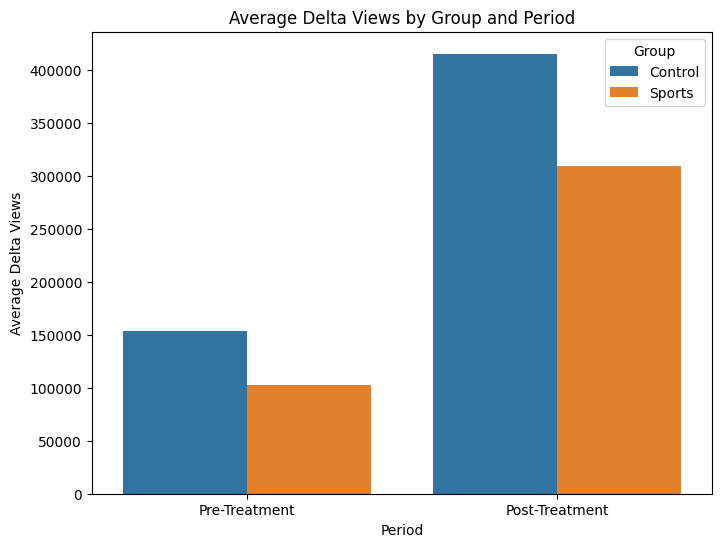

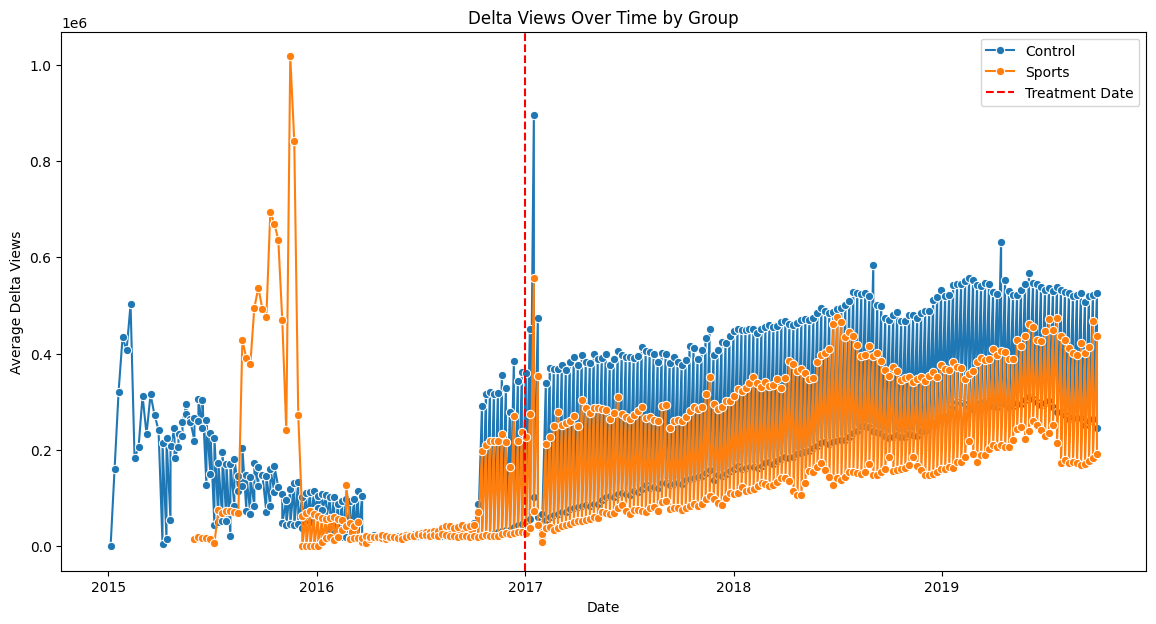

delta_views       0
is_sports         0
post_treatment    0
interaction       0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:            delta_views   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2304.
Date:                Fri, 01 Nov 2024   Prob (F-statistic):               0.00
Time:                        14:30:46   Log-Likelihood:            -3.1397e+08
No. Observations:            18872499   AIC:                         6.279e+08
Df Residuals:                18872495   BIC:                         6.279e+08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

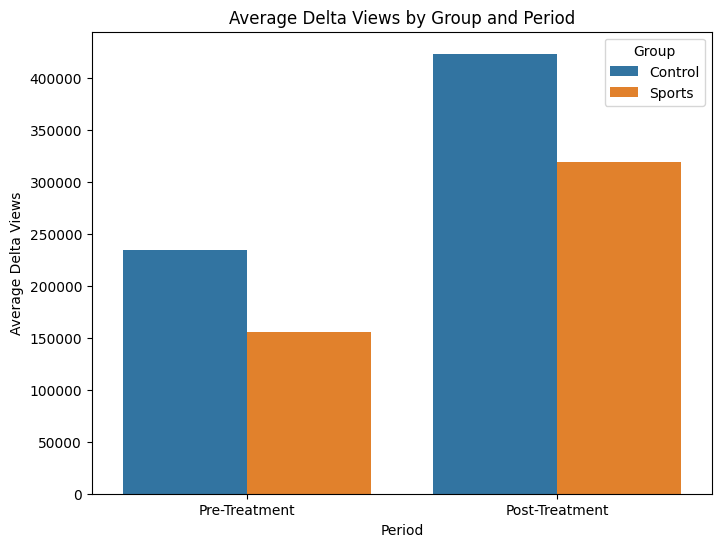

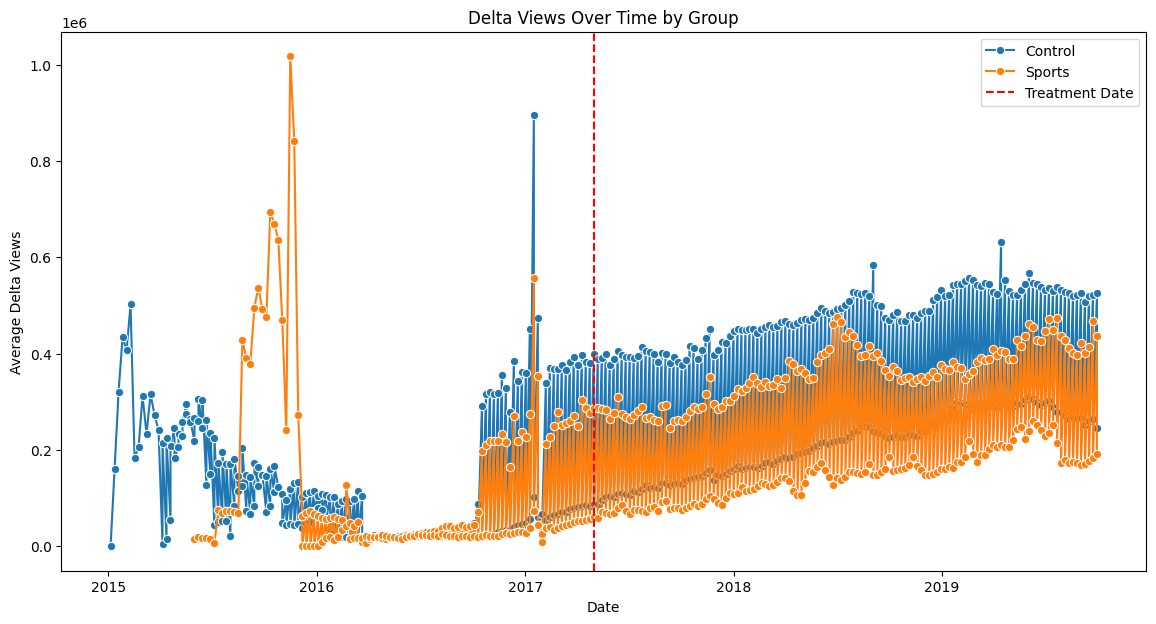

delta_views       0
is_sports         0
post_treatment    0
interaction       0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:            delta_views   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2288.
Date:                Fri, 01 Nov 2024   Prob (F-statistic):               0.00
Time:                        14:30:57   Log-Likelihood:            -3.1397e+08
No. Observations:            18872499   AIC:                         6.279e+08
Df Residuals:                18872495   BIC:                         6.279e+08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

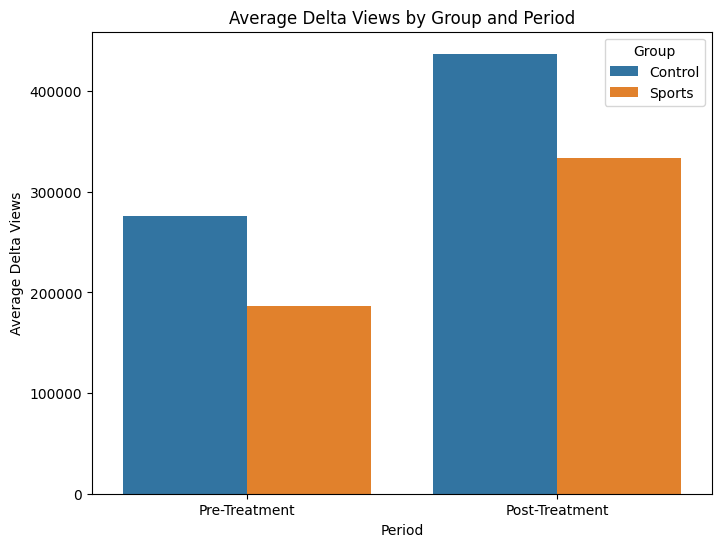

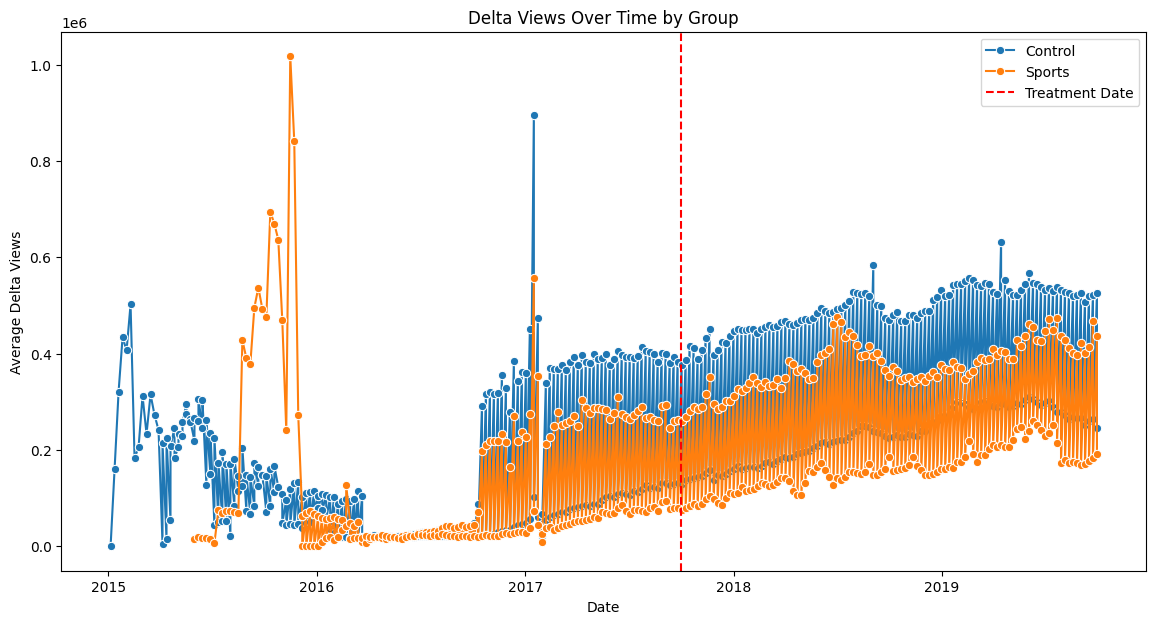

delta_views       0
is_sports         0
post_treatment    0
interaction       0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:            delta_views   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2137.
Date:                Fri, 01 Nov 2024   Prob (F-statistic):               0.00
Time:                        14:31:12   Log-Likelihood:            -3.1397e+08
No. Observations:            18872499   AIC:                         6.279e+08
Df Residuals:                18872495   BIC:                         6.279e+08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

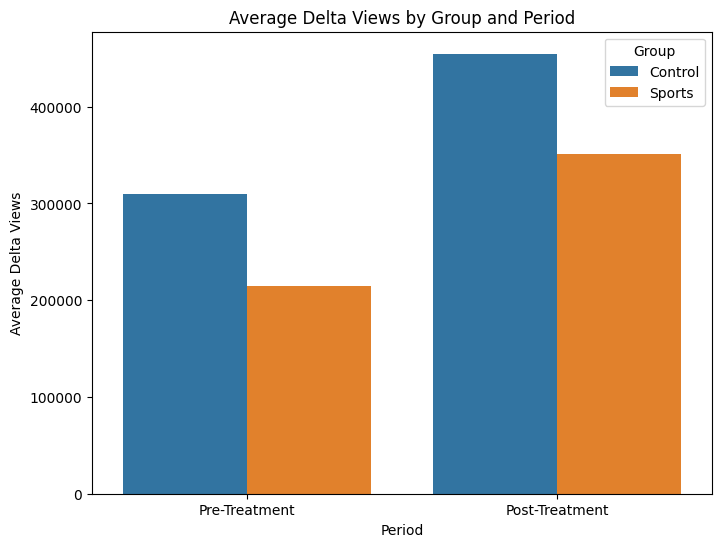

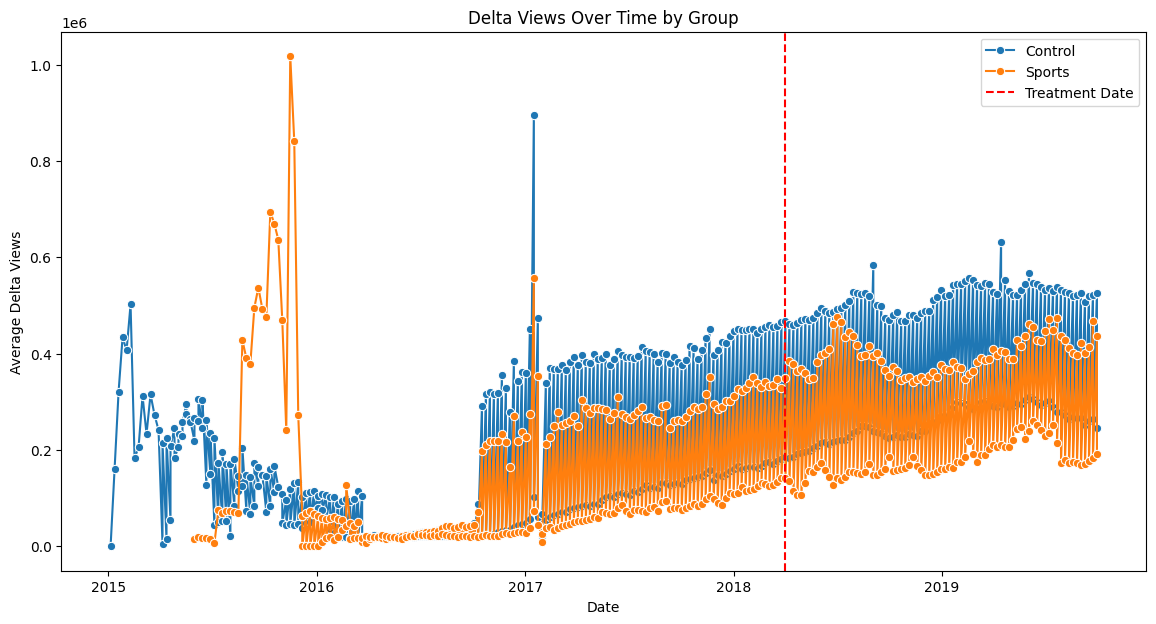

delta_views       0
is_sports         0
post_treatment    0
interaction       0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:            delta_views   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1907.
Date:                Fri, 01 Nov 2024   Prob (F-statistic):               0.00
Time:                        14:31:24   Log-Likelihood:            -3.1397e+08
No. Observations:            18872499   AIC:                         6.279e+08
Df Residuals:                18872495   BIC:                         6.279e+08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

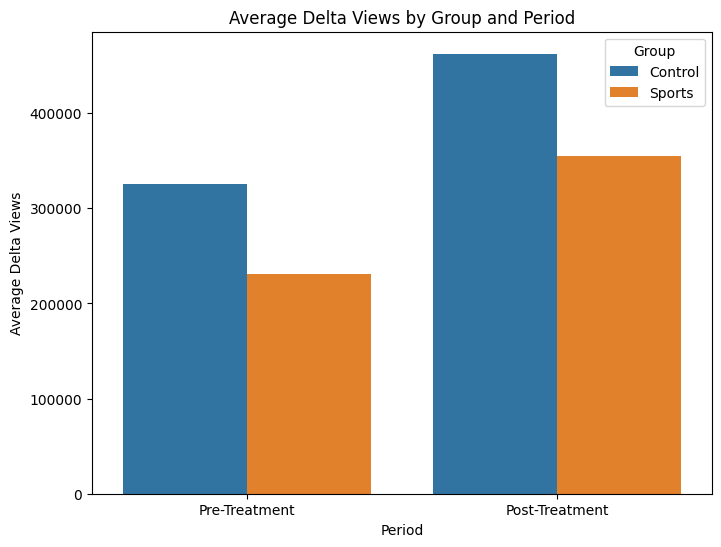

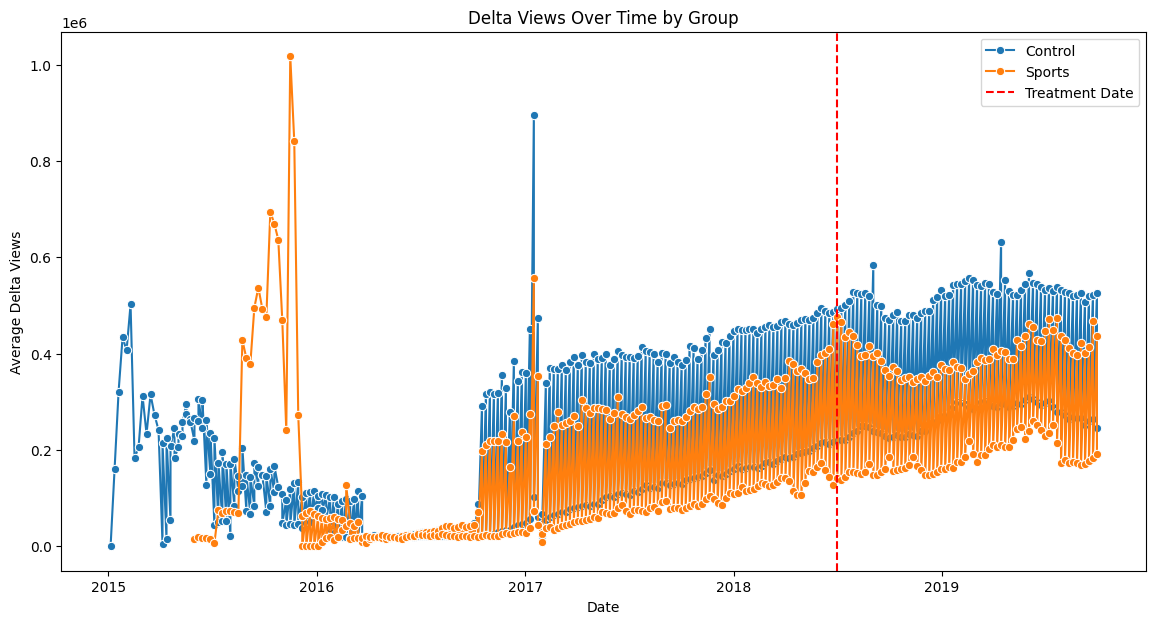

delta_views       0
is_sports         0
post_treatment    0
interaction       0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:            delta_views   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1458.
Date:                Fri, 01 Nov 2024   Prob (F-statistic):               0.00
Time:                        14:31:35   Log-Likelihood:            -3.1397e+08
No. Observations:            18872499   AIC:                         6.279e+08
Df Residuals:                18872495   BIC:                         6.279e+08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

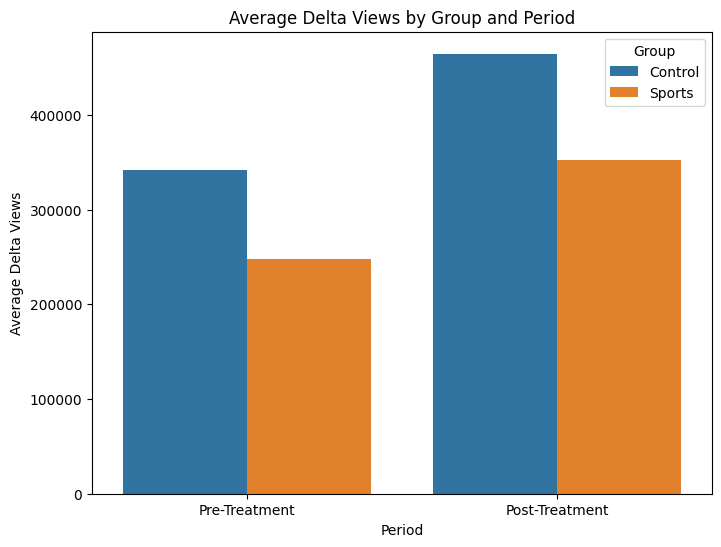

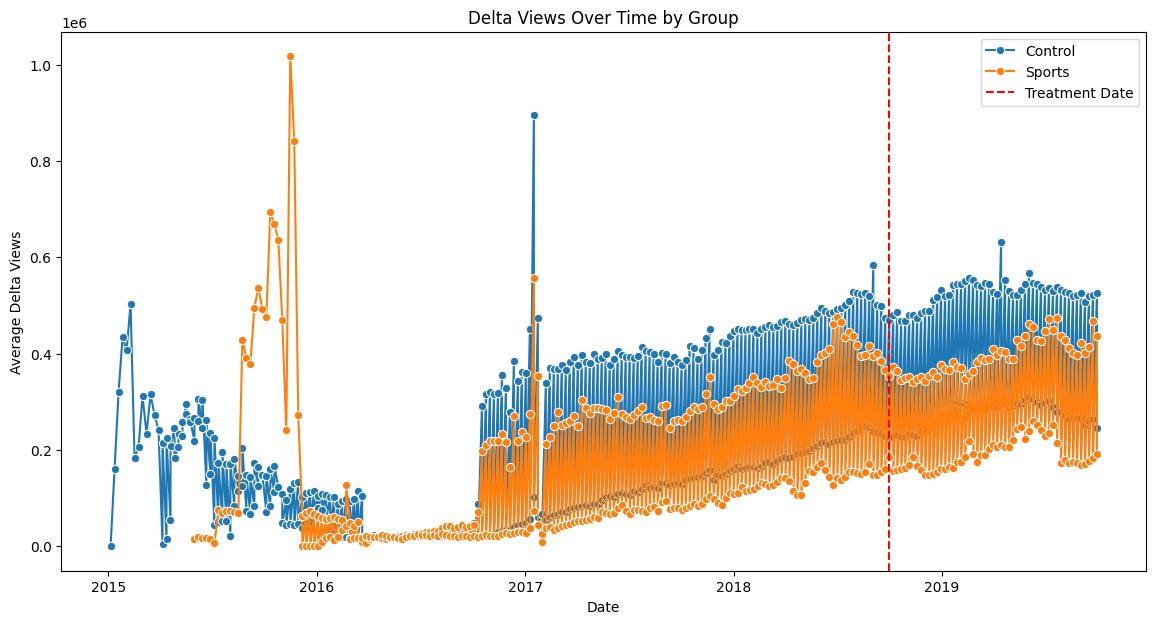

delta_views       0
is_sports         0
post_treatment    0
interaction       0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:            delta_views   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     810.7
Date:                Fri, 01 Nov 2024   Prob (F-statistic):               0.00
Time:                        14:31:47   Log-Likelihood:            -3.1397e+08
No. Observations:            18872499   AIC:                         6.279e+08
Df Residuals:                18872495   BIC:                         6.279e+08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

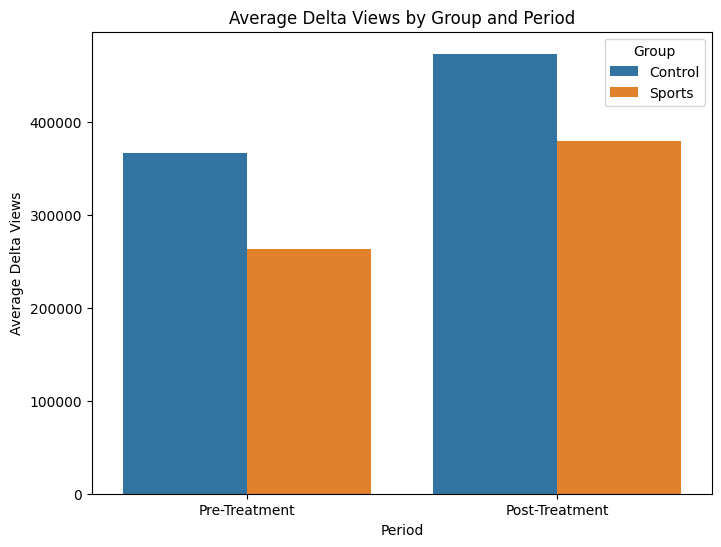

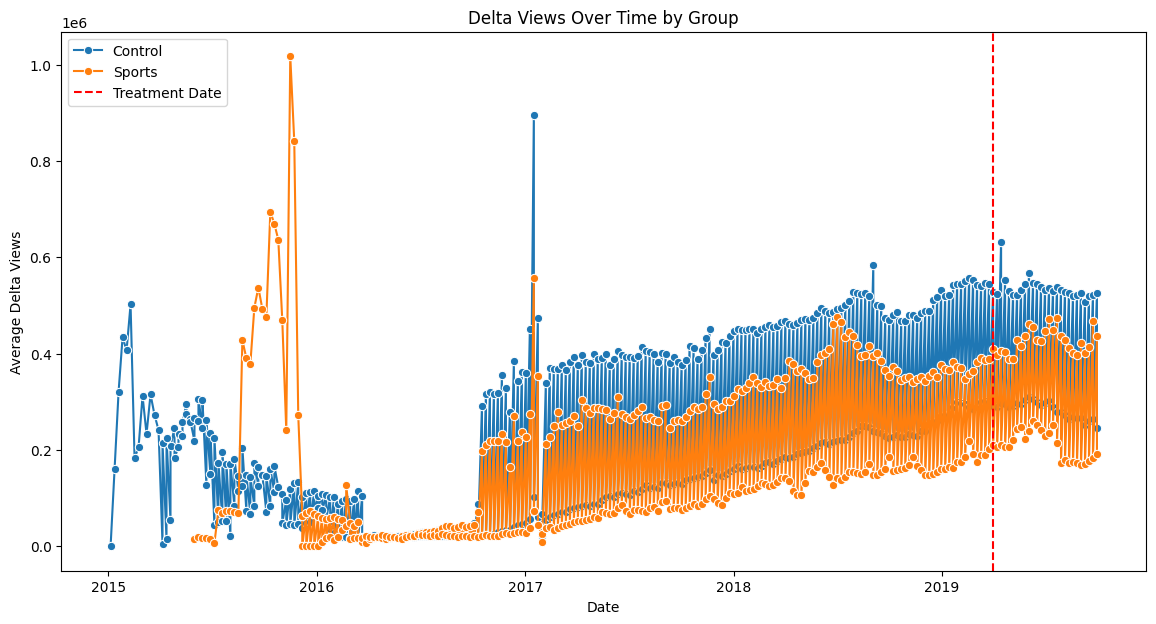

In [149]:
def dif_in_dif(df_timeseries, treatment_date):    
    # Create a binary treatment indicator
    df_timeseries['is_sports'] = np.where(df_timeseries['category'] == 'Sports', 1, 0)

    # Define treatment date (modify as per your specific analysis)
    treatment_date = pd.to_datetime(treatment_date)

    # Create a binary time indicator
    df_timeseries['post_treatment'] = np.where(df_timeseries['datetime'] >= treatment_date, 1, 0)

    # Create interaction term
    df_timeseries['interaction'] = df_timeseries['is_sports'] * df_timeseries['post_treatment']

    # Check for missing values in key variables
    print(df_timeseries[['delta_views', 'is_sports', 'post_treatment', 'interaction']].isnull().sum())

    # Drop rows with missing values in these columns
    df_timeseries = df_timeseries.dropna(subset=['delta_views', 'is_sports', 'post_treatment', 'interaction'])

    # Perform DiD regression
    model = smf.ols('delta_views ~ is_sports + post_treatment + interaction', data=df_timeseries).fit()

    # Print regression summary
    print(model.summary())

    # Create summary for visualization
    summary = df_timeseries.groupby(['post_treatment', 'is_sports'])['delta_views'].mean().reset_index()
    summary['Group'] = summary['is_sports'].apply(lambda x: 'Sports' if x == 1 else 'Control')
    summary['Period'] = summary['post_treatment'].apply(lambda x: 'Post-Treatment' if x == 1 else 'Pre-Treatment')

    # Bar Plot
    plt.figure(figsize=(8,6))
    sns.barplot(x='Period', y='delta_views', hue='Group', data=summary)
    plt.title('Average Delta Views by Group and Period')
    plt.ylabel('Average Delta Views')
    plt.show()

    # Time Series Plot
    time_summary = df_timeseries.groupby(['datetime', 'is_sports'])['delta_views'].mean().reset_index()

    time_summary['Group'] = time_summary['is_sports'].apply(lambda x: 'Sports' if x == 1 else 'Control')

    # Plot
    plt.figure(figsize=(14,7))
    sns.lineplot(x='datetime', y='delta_views', hue='Group', data=time_summary, marker='o')
    plt.axvline(x=treatment_date, color='red', linestyle='--', label='Treatment Date')
    plt.title('Delta Views Over Time by Group')
    plt.xlabel('Date')
    plt.ylabel('Average Delta Views')
    plt.legend()
    plt.show()


dif_in_dif(df_timeseries, '2017-01-01') 
dif_in_dif(df_timeseries, '2017-05-01') 
dif_in_dif(df_timeseries, '2017-10-01')
dif_in_dif(df_timeseries, '2018-04-01')
dif_in_dif(df_timeseries, '2018-07-01')
dif_in_dif(df_timeseries, '2018-10-01')
dif_in_dif(df_timeseries, '2019-04-01')


  

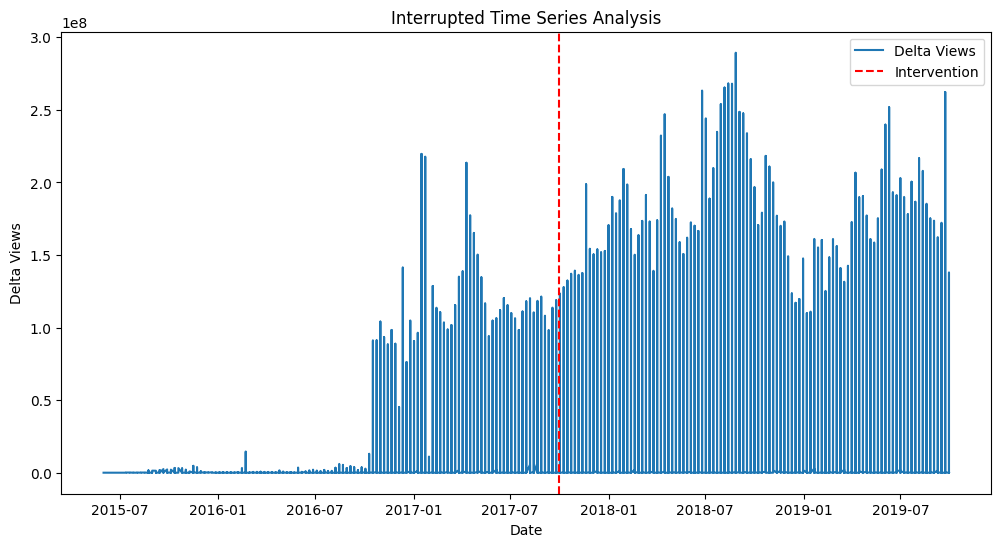

                            OLS Regression Results                            
Dep. Variable:            delta_views   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     236.4
Date:                Fri, 01 Nov 2024   Prob (F-statistic):          2.47e-153
Time:                        12:43:59   Log-Likelihood:            -1.2382e+07
No. Observations:              762263   AIC:                         2.476e+07
Df Residuals:                  762259   BIC:                         2.476e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                7

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Assuming df_timeseries_sports is your Sports category DataFrame
df = df_timeseries_sports.copy()

# Ensure 'datetime' is sorted
df = df.sort_values('datetime')

# Define the intervention date
intervention_date = pd.to_datetime('2017-10-01')

# Create time variables
df['time'] = np.arange(len(df))
df['intervention'] = np.where(df['datetime'] >= intervention_date, 1, 0)
df['time_after_intervention'] = np.where(df['datetime'] >= intervention_date, df['time'] - df[df['datetime'] < intervention_date].shape[0], 0)

# Plot the data
plt.figure(figsize=(12,6))
plt.plot(df['datetime'], df['delta_views'], label='Delta Views')
plt.axvline(x=intervention_date, color='red', linestyle='--', label='Intervention')
plt.xlabel('Date')
plt.ylabel('Delta Views')
plt.title('Interrupted Time Series Analysis')
plt.legend()
plt.show()

# Fit the ITS regression model
model = smf.ols('delta_views ~ time + intervention + time_after_intervention', data=df).fit()
print(model.summary())

# Interpretation:
# - Coefficient of 'intervention': Immediate change in level post-intervention
# - Coefficient of 'time_after_intervention': Change in trend post-intervention


Non-Numeric Columns: Index(['channel', 'category'], dtype='object')

Monthly Delta Views:
    datetime    delta_views  is_sports  post_treatment  interaction
0 2015-06-30   16344.050000        1.0             0.0          0.0
1 2015-07-31   55903.635417        1.0             0.0          0.0
2 2015-08-31  264010.596032        1.0             0.0          0.0
3 2015-09-30  480352.385957        1.0             0.0          0.0
4 2015-10-31  618909.635589        1.0             0.0          0.0

Detected Change Points (indices): [20, 52]

Change Points:
  Change_Point_Date    Delta_Views
0        2017-01-31  251775.939914

Anomalies:
Empty DataFrame
Columns: [datetime, delta_views]
Index: []


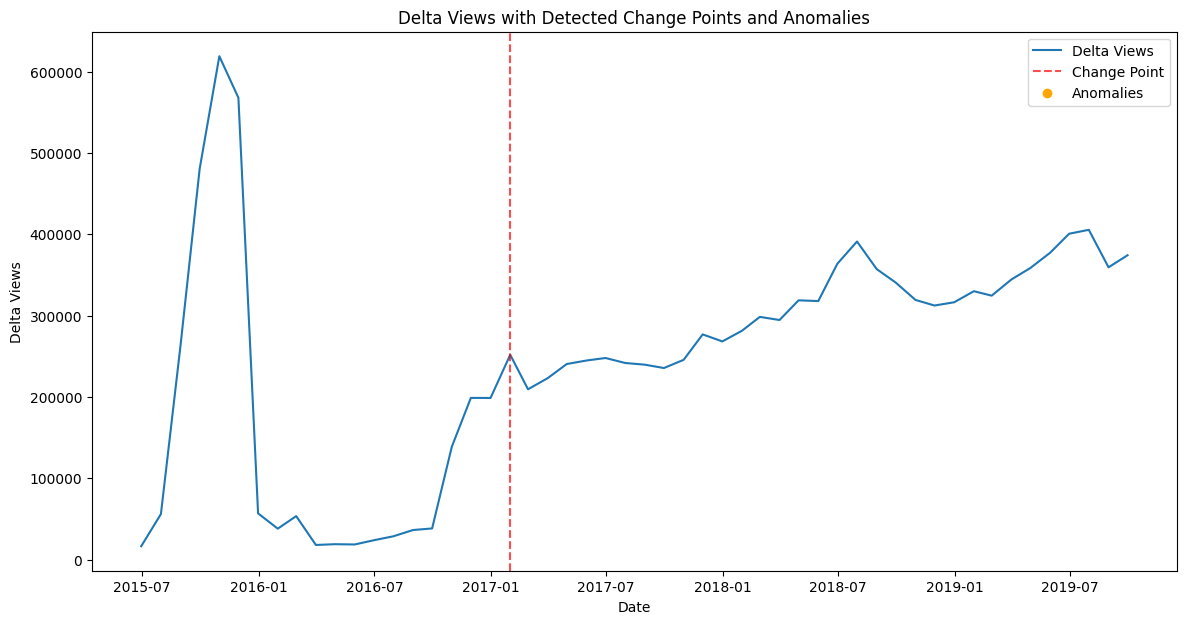

In [152]:
object_cols = df_sports.select_dtypes(include=['object']).columns
print("Non-Numeric Columns:", object_cols)

# ----- Step 3: Resample to Monthly Frequency -----

# Ensure 'datetime' is datetime type
df_sports = df_timeseries_sports.copy()
df_sports['datetime'] = pd.to_datetime(df_sports['datetime'])

# Sort by datetime
df_sports = df_sports.sort_values('datetime')

# Define numeric columns
numeric_cols = ['delta_views', 'is_sports', 'post_treatment', 'interaction']

# Set 'datetime' as the index and resample to monthly frequency, computing the mean of numeric columns
monthly_delta_views = df_sports.set_index('datetime')[numeric_cols].resample('M').mean().reset_index()

print("\nMonthly Delta Views:")
print(monthly_delta_views.head())

 # Change Point Detection with ruptures 

# Extract the signal
signal = monthly_delta_views['delta_views'].values

# Define the model
model = "rbf"  # Suitable for changes in mean and variance

# Initialize and fit the PELT algorithm
algo = rpt.Pelt(model=model).fit(signal)
penalty = 8  # Higher value = fewer change points

# Predict change points
change_points = algo.predict(pen=penalty)

print("\nDetected Change Points (indices):", change_points)

# Convert change points to dates
cp_dates = [monthly_delta_views['datetime'][cp - 1] for cp in change_points[:-1]]
cp_values = [signal[cp - 1] for cp in change_points[:-1]]

# Create a DataFrame for change points
df_cp = pd.DataFrame({
    'Change_Point_Date': cp_dates,
    'Delta_Views': cp_values
})

print("\nChange Points:")
print(df_cp)


# Define the rolling window size (e.g., 3 months)
window_size = 1

# Calculate rolling mean and standard deviation
monthly_delta_views['rolling_mean'] = monthly_delta_views['delta_views'].rolling(window=window_size).mean()
monthly_delta_views['rolling_std'] = monthly_delta_views['delta_views'].rolling(window=window_size).std()

# Define a threshold for anomalies (e.g., 2 standard deviations from the mean)
threshold = 2
monthly_delta_views['anomaly'] = np.where(
    (monthly_delta_views['delta_views'] > monthly_delta_views['rolling_mean'] + threshold * monthly_delta_views['rolling_std']) |
    (monthly_delta_views['delta_views'] < monthly_delta_views['rolling_mean'] - threshold * monthly_delta_views['rolling_std']),
    True,
    False
)

anomalies = monthly_delta_views[monthly_delta_views['anomaly']]

print("\nAnomalies:")
print(anomalies[['datetime', 'delta_views']])

plt.figure(figsize=(14, 7))
plt.plot(monthly_delta_views['datetime'], monthly_delta_views['delta_views'], label='Delta Views')

# Plot change points
for cp in cp_dates:
    plt.axvline(x=cp, color='red', linestyle='--', alpha=0.7, label='Change Point' if cp == cp_dates[0] else "")

# Plot anomalies
plt.scatter(anomalies['datetime'], anomalies['delta_views'], color='orange', label='Anomalies')

plt.title('Delta Views with Detected Change Points and Anomalies')
plt.xlabel('Date')
plt.ylabel('Delta Views')
plt.legend()
plt.show()